# 04. StateGraph 기초

> `StateGraph` = State + Node + Edge — 이 셋만 알면 LangGraph의 절반은 끝난 거예요. 가장 작은 그래프를 직접 만들며 핵심 어휘를 익혀요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `StateGraph`의 세 가지 핵심 구성 요소(State, Node, Edge)를 설명하고 직접 구현할 수 있어요
2. `TypedDict`로 상태 스키마를 정의하고, 기본 덮어쓰기 vs `Annotated` 리듀서의 차이를 이해해요
3. 일반 엣지와 조건부 엣지로 실행 흐름을 제어하고, `START`/`END` 특수 노드를 활용할 수 있어요
4. `Send`로 동적 병렬 처리를 구현하고, `Command`로 상태 업데이트와 라우팅을 동시에 처리할 수 있어요
5. 재귀 제한(`recursion_limit`)과 `GraphRecursionError`를 이해하고 안전한 그래프를 설계할 수 있어요

## 사전 지식

- Python `TypedDict`, `Annotated` 타입 힌트 기초
- 이전 노트북: `03-Messages.ipynb` — HumanMessage, AIMessage, ToolMessage 등 메시지 타입
- `add_messages` 리듀서 개념 (이전 노트북에서 소개됨)

## StateGraph란?

LangGraph의 핵심은 에이전트 워크플로우를 **그래프(Graph)**로 모델링하는 거예요. 그래프는 세 가지 핵심 구성 요소로 이루어져 있어요.

| 구성 요소 | 역할 | 핵심 특징 |
|----------|------|----------|
| **State (상태)** | 그래프 전체에서 공유되는 데이터 구조 | `TypedDict`로 스키마 정의, 리듀서로 업데이트 방식 지정 |
| **Nodes (노드)** | 실제 작업을 수행하는 Python 함수 | 현재 State를 입력받아 업데이트 딕셔너리 반환 |
| **Edges (엣지)** | 노드 간 실행 흐름 정의 | 일반 엣지(고정), 조건부 엣지(동적 분기) |

```mermaid
flowchart TB
    S([시작<br/>START]):::input
    N1[노드 A<br/>Node A]:::process
    N2[노드 B<br/>Node B]:::process
    N3[노드 C<br/>Node C]:::process
    E([종료<br/>END]):::output
    ST[(State<br/>공유 상태)]:::storage

    S --> N1
    N1 --> N2
    N1 -->|조건부| N3
    N2 --> E
    N3 --> E
    N1 <-.읽기/쓰기.-> ST
    N2 <-.읽기/쓰기.-> ST
    N3 <-.읽기/쓰기.-> ST

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
```

> 🔑 **핵심 개념**: StateGraph의 핵심은 **State가 노드들 사이를 흐르는 공유 메모리** 라는 점이에요. 공장의 조립 라인을 상상해보세요. 제품(State)이 컨베이어 벨트(Edge)를 타고 각 작업대(Node)를 거치면서 점점 완성되어 가는 거예요. 각 작업대는 제품의 특정 부분만 작업하고, 나머지는 그대로 다음 작업대로 넘겨요. 각 노드는 State를 읽고 일부를 업데이트하며, 엣지가 다음에 실행할 노드를 결정해요.

## 환경 설정

In [1]:
# 환경 변수 로드 (OPENAI_API_KEY 등)
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
import os

# LangSmith 추적 설정 (선택 사항)
# 실행 과정을 LangSmith에서 시각적으로 디버깅할 수 있어요
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Tutorial-StateGraph"

## 1. 첫 번째 StateGraph 만들기

StateGraph를 만드는 기본 흐름은 항상 같아요:

1. **State 정의** → `TypedDict`로 공유 데이터 구조 설계
2. **Node 함수 작성** → State를 입력받아 업데이트 딕셔너리 반환
3. **Graph 조립** → `StateGraph` 생성 후 노드/엣지 추가
4. **compile()** → 실행 가능한 형태로 변환
5. **invoke()** → 초기 State를 넣어 실행

> 🎯 **강의 포인트**: `compile()`을 호출하기 전까지는 그래프가 실행될 수 없어요. `compile()`은 노드 연결을 검증하고 실행 순서를 결정하는 중요한 단계예요.

In [3]:
# LangGraph 핵심 구성 요소를 가져와요
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


# ---------------------------------------------------
# Step 1: State 정의
# ---------------------------------------------------
# 그래프 전체에서 공유되는 데이터 구조예요
# TypedDict로 각 필드의 타입을 명시적으로 선언해요
class SimpleState(TypedDict):
    input: str   # 처리할 입력 텍스트
    result: str  # 처리 결과


# ---------------------------------------------------
# Step 2: Node 함수 작성
# ---------------------------------------------------
# 노드는 현재 State를 입력받아 '업데이트할 필드만' 딕셔너리로 반환해요
# 반환하지 않은 필드는 그대로 유지돼요
def process_node(state: SimpleState):
    """입력값을 처리해 결과를 반환하는 노드"""
    return {"result": f"처리 완료: '{state['input']}'"}  # result 필드만 업데이트


# ---------------------------------------------------
# Step 3: Graph 조립
# ---------------------------------------------------
# StateGraph에 State 타입을 매개변수로 전달해요
builder = StateGraph(SimpleState)
builder.add_node("process", process_node)  # 노드 이름: "process"

# START/END는 그래프의 진입점/종료점을 나타내는 특수 노드예요
builder.add_edge(START, "process")  # 진입: START → process
builder.add_edge("process", END)    # 종료: process → END

# ---------------------------------------------------
# Step 4: compile() — 실행 가능한 형태로 변환
# ---------------------------------------------------
graph = builder.compile()

# 그래프 생성 완료!

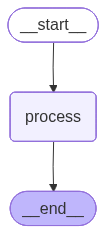

In [4]:
# 그래프 흐름: START → process → END
# process 노드: 입력 텍스트를 받아 처리 결과를 반환해요
# 그래프 구조를 시각화해요
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [5]:
# ---------------------------------------------------
# Step 5: invoke() — 초기 State를 넣어 실행
# ---------------------------------------------------
# 초기 State 딕셔너리를 전달하면 START부터 END까지 노드를 순서대로 실행해요
result = graph.invoke({"input": "안녕하세요, LangGraph!"})

print(f"입력: {result['input']}")
print(f"결과: {result['result']}")

입력: 안녕하세요, LangGraph!
결과: 처리 완료: '안녕하세요, LangGraph!'


## 2. State와 리듀서(Reducer)

State에서 가장 중요한 개념 중 하나가 **리듀서(Reducer)**예요. 노드가 State를 업데이트할 때 그 값을 어떻게 합칠지 결정해요.

| 리듀서 방식 | 선언 방법 | 동작 | 사용 예시 |
|------------|---------|------|----------|
| 기본 덮어쓰기 | 타입만 선언 | 새 값이 기존 값 완전 교체 | 단순 문자열, 숫자 |
| 커스텀 리듀서 | `Annotated[list, operator.add]` | 새 리스트가 기존 리스트에 추가 | 로그, 중간 결과 목록 |
| `add_messages` | `Annotated[list, add_messages]` | 메시지 추가 (ID 중복 시 업데이트) | 대화 이력 관리 |

> 🔑 **핵심 개념**: `Annotated[타입, 리듀서함수]` 패턴이 핵심이에요. 리듀서를 지정하지 않으면 항상 덮어쓰기가 발생해요.

> ⚠️ **자주 하는 실수**: 초보자가 가장 많이 겪는 버그는 `messages: list`처럼 리듀서 없이 선언하는 거예요. 이러면 노드가 새 메시지를 반환할 때마다 **이전 대화가 전부 사라져요**. 반드시 `messages: Annotated[list, add_messages]`로 선언하세요!

### 2-1. 기본 덮어쓰기 리듀서

리듀서를 지정하지 않으면 새 값이 기존 값을 완전히 교체해요.

> ⚠️ **자주 하는 실수**: 리스트 필드에 리듀서를 지정하지 않으면 노드가 값을 반환할 때마다 기존 리스트 전체가 사라져요. 누적해야 하는 데이터에는 반드시 리듀서를 지정하세요!

In [6]:
# 기본 덮어쓰기 동작을 이해하는 예제예요
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


# 리듀서를 지정하지 않은 State → 모든 필드가 덮어쓰기 방식
class OverwriteState(TypedDict):
    count: int   # 숫자 필드: 덮어쓰기
    label: str   # 문자열 필드: 덮어쓰기


def node_a(state: OverwriteState):
    """count를 10으로 업데이트, label은 건드리지 않아요"""
    print(f"  [node_a 진입] count={state['count']}, label={state['label']}")
    return {"count": state["count"] * 2}  # count만 반환, label은 유지돼요


def node_b(state: OverwriteState):
    """label을 업데이트, count는 건드리지 않아요"""
    print(f"  [node_b 진입] count={state['count']}, label={state['label']}")
    return {"label": "완료"}  # label만 반환, count는 유지돼요


# 그래프 구성
builder = StateGraph(OverwriteState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_b", END)
graph = builder.compile()

# 초기 상태로 실행
result = graph.invoke({"count": 5, "label": "진행 중"})
print(f"\n최종 결과: count={result['count']}, label={result['label']}")
# count: 5 → 10 (node_a에서 2배), label: '진행 중' → '완료' (node_b에서 교체)

  [node_a 진입] count=5, label=진행 중
  [node_b 진입] count=10, label=진행 중

최종 결과: count=10, label=완료


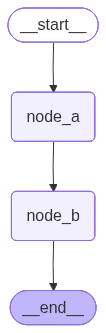

In [7]:
# 그래프 흐름: START → node_a → node_b → END
# node_a: count 값을 2배로 업데이트해요
# node_b: label을 '완료'로 업데이트해요
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

### 2-2. 커스텀 리듀서 — 리스트 누적

In [8]:
# Annotated와 operator.add로 리스트 누적 리듀서를 지정해요
from typing import Annotated
from typing_extensions import TypedDict
from operator import add
from langgraph.graph import StateGraph, START, END


# Annotated[list[str], add]: 새 리스트가 기존 리스트에 이어붙여져요
class AccumulateState(TypedDict):
    step: int                            # 덮어쓰기 (현재 스텝 번호)
    log: Annotated[list[str], add]       # 누적 (로그 항목 추가)


def step_one(state: AccumulateState):
    """첫 번째 처리 단계"""
    return {
        "step": 1,
        "log": ["step_one 실행"]  # 기존 log 리스트에 추가돼요
    }


def step_two(state: AccumulateState):
    """두 번째 처리 단계"""
    return {
        "step": 2,
        "log": ["step_two 실행"]  # 기존 log 리스트에 또 추가돼요
    }


# 그래프 구성
builder = StateGraph(AccumulateState)
builder.add_node("step_one", step_one)
builder.add_node("step_two", step_two)
builder.add_edge(START, "step_one")
builder.add_edge("step_one", "step_two")
builder.add_edge("step_two", END)
graph = builder.compile()

# 초기 log는 빈 리스트로 시작해요
result = graph.invoke({"step": 0, "log": ["초기화"]})
print(f"최종 스텝: {result['step']}")
print(f"누적 로그: {result['log']}")
# log: ['초기화'] → ['초기화', 'step_one 실행'] → ['초기화', 'step_one 실행', 'step_two 실행']

최종 스텝: 2
누적 로그: ['초기화', 'step_one 실행', 'step_two 실행']


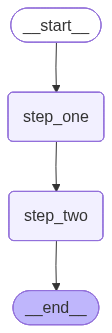

In [9]:
# 그래프 흐름: START → step_one → step_two → END
# step_one: step=1로 업데이트하고 log에 기록을 누적해요
# step_two: step=2로 업데이트하고 log에 기록을 누적해요
display(Image(graph.get_graph().draw_mermaid_png()))

### 2-3. `add_messages` 리듀서와 `MessagesState`

`add_messages`는 LangGraph가 제공하는 특수 리듀서예요. 단순히 리스트에 추가하는 것을 넘어서, **메시지 ID를 기반으로 중복을 처리**해요.

```python
# 동일한 ID가 있으면 교체, 없으면 추가
add_messages([HumanMessage("안녕", id="1")], [AIMessage("반가워", id="1")])
# 결과: [AIMessage("반가워", id="1")]  ← ID "1"인 메시지가 교체됨
```

> 💡 **실무 팁**: `MessagesState`를 상속하면 `messages: Annotated[list[AnyMessage], add_messages]` 필드가 자동으로 포함돼요. 직접 정의할 필요 없이 상속만 하면 바로 사용할 수 있어요.

In [10]:
# add_messages 리듀서 직접 사용 예시예요
from langchain.messages import HumanMessage, AIMessage
from langgraph.graph import add_messages

# 기본 동작: 두 리스트를 병합해요
msgs1 = [HumanMessage(content="안녕하세요!", id="msg-1")]
msgs2 = [AIMessage(content="반갑습니다~", id="msg-2")]

merged = add_messages(msgs1, msgs2)
# === 기본 병합 ===
for msg in merged:
    print(f"  [{msg.type}] {msg.content} (id={msg.id})")

print()

# ID 중복 시 교체 동작: 같은 ID "msg-1"을 가진 메시지가 교체돼요
msgs_update = [AIMessage(content="수정된 응답", id="msg-1")]  # msg-1을 업데이트

updated = add_messages(merged, msgs_update)
# === ID 중복 시 교체 ===
for msg in updated:
    print(f"  [{msg.type}] {msg.content} (id={msg.id})")

  [human] 안녕하세요! (id=msg-1)
  [ai] 반갑습니다~ (id=msg-2)

  [ai] 수정된 응답 (id=msg-1)
  [ai] 반갑습니다~ (id=msg-2)


In [11]:
# MessagesState 상속 예시예요
from langgraph.graph import MessagesState


# MessagesState를 상속하면 messages 필드 (add_messages 리듀서 포함)가 자동으로 제공돼요
class ChatState(MessagesState):
    # messages 필드는 상속으로 자동 포함
    user_name: str  # 추가 필드만 정의하면 돼요
    session_id: str


# ChatState 필드 확인:
print(f"  상속된 필드: messages (add_messages 리듀서 포함)")
print(f"  추가 필드: user_name, session_id")

  상속된 필드: messages (add_messages 리듀서 포함)
  추가 필드: user_name, session_id


## 3. Nodes (노드)

노드는 그래프의 **실제 작업을 수행하는 Python 함수**예요. 노드 함수의 정의 방법은 다음과 같아요:

```python
def my_node(state: State) -> dict:              # 기본 형태
def my_node(state: State, config: RunnableConfig) -> dict:  # config 활용
```

| 매개변수 | 타입 | 설명 |
|---------|------|------|
| `state` | `State` (TypedDict) | 현재 그래프 상태 (필수) |
| `config` | `RunnableConfig` | 실행 구성 — `thread_id`, `recursion_limit` 등 (선택) |

> 🎯 **강의 포인트**: 노드는 **전체 State를 교체하지 않아요**. 업데이트할 필드만 딕셔너리로 반환하면, 나머지 필드는 자동으로 유지돼요. 이것이 LangGraph 상태 관리의 핵심 패턴이에요.

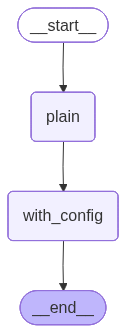

  plain_node 실행: message='hello langgraph'
  node_with_config 실행: thread_id='abc-123'

결과: message='HELLO LANGGRAPH', processed_by='thread-abc-123'


In [12]:
# config를 활용하는 노드 예시예요
from typing_extensions import TypedDict
from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, START, END


class ConfigState(TypedDict):
    message: str
    processed_by: str  # 어느 thread에서 처리했는지 기록


def plain_node(state: ConfigState):
    """기본 노드: state만 사용해요"""
    print(f"  plain_node 실행: message='{state['message']}'")
    return {"message": state["message"].upper()}  # 대문자로 변환


def node_with_config(state: ConfigState, config: RunnableConfig):
    """config를 사용하는 노드: thread_id 등 실행 구성에 접근할 수 있어요"""
    # config["configurable"]에서 thread_id를 가져와요 (없으면 "unknown")
    thread_id = config.get("configurable", {}).get("thread_id", "unknown")
    print(f"  node_with_config 실행: thread_id='{thread_id}'")
    return {"processed_by": f"thread-{thread_id}"}


# 그래프 구성
builder = StateGraph(ConfigState)
builder.add_node("plain", plain_node)
builder.add_node("with_config", node_with_config)
builder.add_edge(START, "plain")
builder.add_edge("plain", "with_config")
builder.add_edge("with_config", END)
graph = builder.compile()

# 그래프 흐름: START → plain → with_config → END
# plain 노드: 메시지를 대문자로 변환해요
# with_config 노드: config에서 thread_id를 읽어 기록해요
display(Image(graph.get_graph().draw_mermaid_png()))
# config 매개변수로 thread_id를 전달해요
result = graph.invoke(
    {"message": "hello langgraph", "processed_by": ""},
    config={"configurable": {"thread_id": "abc-123"}}
)
print(f"\n결과: message='{result['message']}', processed_by='{result['processed_by']}'")

## 4. Edges (엣지)

엣지는 노드 간의 **실행 흐름**을 정의해요. LangGraph는 두 가지 주요 엣지 유형을 제공해요:

```mermaid
flowchart LR
    N1[노드 A]:::process
    N2[노드 B]:::process
    N3[노드 C]:::process
    N4[노드 D]:::process
    R{라우팅 함수}:::error

    N1 -->|일반 엣지 항상 B로| N2
    N3 --> R
    R -->|조건 1| N4
    R -->|조건 2| N2

    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef error fill:#f8d7da,stroke:#dc3545,color:#721c24
```

### 4-1. 일반 엣지 (Normal Edge)

일반 엣지는 항상 고정된 경로를 따라가요. `add_edge(source, target)` 메서드로 정의해요.

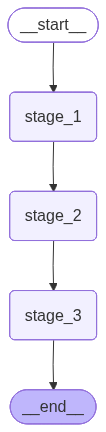

  stage_1: '  HELLO LangGraph  ' → '  hello langgraph  '
  stage_2: '  hello langgraph  ' → 'hello langgraph'
  stage_3: 'hello langgraph' → 'hello langgraph!'

최종 결과: 'hello langgraph!'


In [13]:
# 일반 엣지로 순차 파이프라인을 구성해요
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


class PipelineState(TypedDict):
    text: str  # 처리 과정을 추적하는 문자열


def stage_1(state: PipelineState):
    """1단계: 소문자 변환"""
    result = state["text"].lower()
    print(f"  stage_1: '{state['text']}' → '{result}'")
    return {"text": result}


def stage_2(state: PipelineState):
    """2단계: 공백 제거"""
    result = state["text"].strip()
    print(f"  stage_2: '{state['text']}' → '{result}'")
    return {"text": result}


def stage_3(state: PipelineState):
    """3단계: 느낌표 추가"""
    result = state["text"] + "!"
    print(f"  stage_3: '{state['text']}' → '{result}'")
    return {"text": result}


# 그래프 구성: START → stage_1 → stage_2 → stage_3 → END
builder = StateGraph(PipelineState)
builder.add_node("stage_1", stage_1)
builder.add_node("stage_2", stage_2)
builder.add_node("stage_3", stage_3)

# 일반 엣지 — 항상 이 순서대로 실행돼요
builder.add_edge(START, "stage_1")
builder.add_edge("stage_1", "stage_2")
builder.add_edge("stage_2", "stage_3")
builder.add_edge("stage_3", END)

graph = builder.compile()

# 그래프 흐름: START → stage_1 → stage_2 → stage_3 → END
# stage_1: 소문자 변환, stage_2: 공백 제거, stage_3: 느낌표 추가
display(Image(graph.get_graph().draw_mermaid_png()))
result = graph.invoke({"text": "  HELLO LangGraph  "})
print(f"\n최종 결과: '{result['text']}'")

### 4-2. 조건부 엣지 (Conditional Edge)

조건부 엣지는 **라우팅 함수(routing function)**의 반환값에 따라 다른 노드로 분기해요.

```python
builder.add_conditional_edges(
    source_node,       # 어느 노드 뒤에 조건 판단을 할지
    routing_function,  # 상태를 보고 문자열 키를 반환하는 함수
    {"키1": "노드A", "키2": "노드B"}  # 키 → 노드 매핑 (생략 가능)
)
```

> 💡 **실무 팁**: 라우팅 함수가 노드 이름을 직접 반환하면 `path_map`을 생략할 수 있어요. 하지만 `path_map`을 명시하면 코드 가독성이 더 좋아져요.

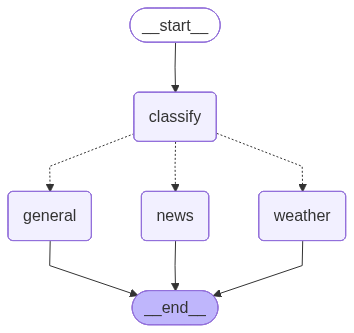

In [14]:
# 조건부 엣지로 입력에 따라 다른 경로를 선택해요
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


class RouteState(TypedDict):
    query: str    # 사용자 질의
    category: str # 분류 결과
    answer: str   # 최종 답변


def classify_node(state: RouteState):
    """질의를 분류하는 노드"""
    query = state["query"].lower()
    # 간단한 키워드 기반 분류예요
    if "날씨" in query:
        category = "weather"
    elif "뉴스" in query:
        category = "news"
    else:
        category = "general"
    print(f"  분류 결과: '{query}' → {category}")
    return {"category": category}


def weather_node(state: RouteState):
    """날씨 관련 질의 처리"""
    return {"answer": f"날씨 정보: {state['query']}에 대한 날씨는 맑음이에요."}  


def news_node(state: RouteState):
    """뉴스 관련 질의 처리"""
    return {"answer": f"뉴스 정보: {state['query']}에 대한 최신 뉴스예요."}


def general_node(state: RouteState):
    """일반 질의 처리"""
    return {"answer": f"일반 답변: {state['query']}에 대해 답변 드릴게요."}


def routing_function(state: RouteState) -> str:
    """분류 결과를 보고 라우팅 키를 반환해요"""
    return state["category"]  # "weather", "news", "general" 중 하나


# 그래프 구성
builder = StateGraph(RouteState)
builder.add_node("classify", classify_node)
builder.add_node("weather", weather_node)
builder.add_node("news", news_node)
builder.add_node("general", general_node)

builder.add_edge(START, "classify")

# 조건부 엣지: classify 노드 이후, routing_function의 결과에 따라 분기
builder.add_conditional_edges(
    "classify",
    routing_function,
    {
        "weather": "weather",  # "weather" 반환 시 weather 노드로
        "news": "news",        # "news" 반환 시 news 노드로
        "general": "general",  # "general" 반환 시 general 노드로
    }
)
builder.add_edge("weather", END)
builder.add_edge("news", END)
builder.add_edge("general", END)

graph = builder.compile()

# 시각화
# 그래프 흐름: START → classify → weather/news/general → END
# classify 노드: 질의를 키워드로 분류해요
# 조건부 엣지: 분류 결과에 따라 weather, news, general 노드로 분기해요
display(Image(graph.get_graph().draw_mermaid_png()))

In [15]:
# 세 가지 경로를 모두 테스트해요
test_queries = [
    "오늘 서울 날씨 어때요?",
    "오늘 뉴스 알려줘",
    "LangGraph가 뭐예요?"
]

for query in test_queries:
    result = graph.invoke({"query": query})
    print(f"답변: {result['answer']}")
    print()

  분류 결과: '오늘 서울 날씨 어때요?' → weather
답변: 날씨 정보: 오늘 서울 날씨 어때요?에 대한 날씨는 맑음이에요.

  분류 결과: '오늘 뉴스 알려줘' → news
답변: 뉴스 정보: 오늘 뉴스 알려줘에 대한 최신 뉴스예요.

  분류 결과: 'langgraph가 뭐예요?' → general
답변: 일반 답변: LangGraph가 뭐예요?에 대해 답변 드릴게요.



## 5. Send — 동적 병렬 처리

`Send`는 **하나의 노드에서 여러 노드 인스턴스를 병렬로 생성**하는 기능이에요. Map-Reduce 패턴을 구현할 때 특히 유용해요.

```mermaid
flowchart TB
    S([START]):::input
    GEN[generate_items<br/>항목 생성]:::process
    P1[process_item<br/>항목 1]:::process
    P2[process_item<br/>항목 2]:::process
    P3[process_item<br/>항목 3]:::process
    AGG[집계<br/>add 리듀서]:::storage
    E([END]):::output

    S --> GEN
    GEN -->|Send 1| P1
    GEN -->|Send 2| P2
    GEN -->|Send 3| P3
    P1 --> AGG
    P2 --> AGG
    P3 --> AGG
    AGG --> E

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
```

> 🔑 **핵심 개념**: `Send("노드이름", 개별_상태_딕셔너리)`로 각 병렬 인스턴스에 다른 State를 전달할 수 있어요. 결과는 `add` 리듀서를 통해 자동으로 병합돼요.

In [16]:
# Send를 사용한 Map-Reduce 패턴 예시예요
from typing import Annotated
from typing_extensions import TypedDict
from operator import add
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send


# 전체 작업 상태
class BatchState(TypedDict):
    topics: list[str]                          # 처리할 주제 목록
    results: Annotated[list[str], add]          # 처리 결과 (add 리듀서로 병합)


# 개별 작업 상태 (각 병렬 인스턴스가 받는 상태)
class SingleTopicState(TypedDict):
    topic: str  # 단일 주제


def prepare_topics(state: BatchState):
    """처리할 주제 목록을 준비하는 노드"""
    print(f"  처리할 주제: {state['topics']}")
    return {}  # topics는 이미 설정되어 있으므로 그대로 반환


def process_single_topic(state: SingleTopicState):
    """단일 주제를 처리하는 노드 (병렬로 여러 번 실행돼요)"""
    topic = state["topic"]
    result = f"{topic}: 처리 완료"
    print(f"  병렬 처리 중: '{topic}'")
    return {"results": [result]}  # 리스트로 반환해야 add 리듀서로 병합돼요


def dispatch_to_topics(state: BatchState):
    """각 주제에 대해 Send를 생성해 병렬 실행을 트리거해요"""
    # Send(노드이름, 개별_상태) 리스트를 반환하면 병렬 실행이 시작돼요
    return [
        Send("process_single_topic", {"topic": topic})
        for topic in state["topics"]
    ]


# 그래프 구성
builder = StateGraph(BatchState)
builder.add_node("prepare", prepare_topics)
builder.add_node("process_single_topic", process_single_topic)

builder.add_edge(START, "prepare")

# 조건부 엣지에서 Send 리스트를 반환해 병렬 처리를 시작해요
builder.add_conditional_edges("prepare", dispatch_to_topics)
builder.add_edge("process_single_topic", END)

graph = builder.compile()

# 세 주제를 병렬로 처리해요
result = graph.invoke({
    "topics": ["파이썬", "LangGraph", "AI 에이전트"]
})
print(f"\n처리 결과 ({len(result['results'])}개):")
for r in result["results"]:
    print(f"  - {r}")

  처리할 주제: ['파이썬', 'LangGraph', 'AI 에이전트']
  병렬 처리 중: '파이썬'
  병렬 처리 중: 'AI 에이전트'
  병렬 처리 중: 'LangGraph'

처리 결과 (3개):
  - 파이썬: 처리 완료
  - LangGraph: 처리 완료
  - AI 에이전트: 처리 완료


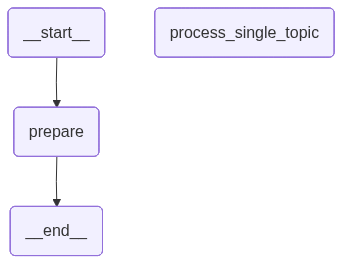

In [17]:
# 그래프 흐름: START → prepare → process_single_topic(병렬) → END
# prepare 노드: 처리할 주제 목록을 준비해요
# process_single_topic: Send API로 각 주제를 병렬 처리해요
# 결과는 add 리듀서로 자동 병합돼요
display(Image(graph.get_graph().draw_mermaid_png()))

## 6. Command — 상태 업데이트 + 라우팅 결합

`Command`는 **상태 업데이트와 다음 노드 지정을 하나의 반환값으로 처리**하는 방법이에요. 조건부 엣지를 별도로 정의하지 않고도 노드 내부에서 동적 라우팅을 할 수 있어요.

```python
from langgraph.types import Command

def my_node(state: State) -> Command:
    return Command(
        update={"field": "새 값"},  # State 업데이트
        goto="다음_노드"              # 다음에 실행할 노드
    )
```

> 🎯 **강의 포인트**: `Command`와 조건부 엣지는 같은 목적(동적 라우팅)을 달성해요. 아래 표를 참고해서 상황에 맞는 방식을 선택하세요.

| 구분 | 조건부 엣지 | Command |
|------|------------|---------|
| 라우팅 로직 위치 | 별도의 라우팅 함수 | 노드 내부 |
| 상태 업데이트 | 노드에서 반환 + 별도 라우팅 | 하나의 반환값으로 동시 처리 |
| 코드 간결성 | 함수 2개 필요 (노드 + 라우터) | 함수 1개로 충분 |
| 권장 상황 | 라우팅만 필요할 때 | 업데이트 + 라우팅이 결합될 때 |

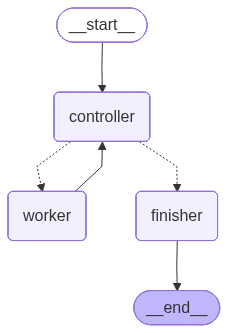

In [18]:
# Command를 사용해 루프 구조를 구현해요
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command


class LoopState(TypedDict):
    count: int    # 반복 횟수
    status: str   # 현재 상태 메시지


def controller_node(state: LoopState) -> Command[Literal["worker", "finisher"]]:
    """반복 횟수를 보고 worker 또는 finisher로 라우팅하는 노드
    
    Command의 타입 힌트 Command[Literal["worker", "finisher"]]는
    이 노드가 이동할 수 있는 노드를 명시해요.
    """
    new_count = state["count"] + 1
    print(f"  controller: count={new_count}")
    
    if new_count < 3:
        # count가 3 미만이면 worker 노드로 이동해요
        return Command(
            update={"count": new_count, "status": f"반복 {new_count}회 진행 중"},
            goto="worker"  # 다음 노드 지정
        )
    else:
        # count가 3 이상이면 finisher 노드로 이동해요
        return Command(
            update={"count": new_count, "status": "완료"},
            goto="finisher"
        )


def worker_node(state: LoopState):
    """반복 작업을 수행하는 노드"""
    print(f"  worker: 작업 수행 (count={state['count']})")
    return {}  # 상태 변경 없이 controller로 돌아가요


def finisher_node(state: LoopState):
    """작업을 마무리하는 노드"""
    print(f"  finisher: 모든 작업 완료!")
    return {}


# 그래프 구성
builder = StateGraph(LoopState)
builder.add_node("controller", controller_node)
builder.add_node("worker", worker_node)
builder.add_node("finisher", finisher_node)

builder.add_edge(START, "controller")       # 시작 → controller
builder.add_edge("worker", "controller")    # worker → controller (루프)
builder.add_edge("finisher", END)           # finisher → 종료

graph = builder.compile()
# 그래프 흐름: START → controller → worker → controller → ... → finisher → END
# controller 노드: count를 확인하고 Command로 worker 또는 finisher로 분기해요
# worker 노드: 작업을 수행하고 controller로 루프백해요
display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
# 그래프 실행: count=0에서 시작해 3회 반복 후 종료
result = graph.invoke({"count": 0, "status": "시작"})
print(f"\n최종 상태: count={result['count']}, status='{result['status']}'")

  controller: count=1
  worker: 작업 수행 (count=1)
  controller: count=2
  worker: 작업 수행 (count=2)
  controller: count=3
  finisher: 모든 작업 완료!

최종 상태: count=3, status='완료'


### 6-1. 비교: Command vs 조건부 엣지

위의 Command 예제와 **동일한 동작**을 조건부 엣지로도 구현할 수 있어요. 아래 코드에서 직접 비교해보세요.

> ⚠️ **자주 하는 실수**: 조건부 엣지에서도 노드 안에 분기 로직을 넣을 수 있어요. 하지만 그러면 **같은 조건이 노드와 라우팅 함수에 중복**돼요. Command는 이 중복을 없애기 위해 설계된 거예요.
>
> ```python
> # 조건부 엣지 버전 — 같은 조건 (count < 3)이 두 곳에 반복돼요
> def controller_node(state):
>     if state["count"] < 3:        # ← 여기에도 조건
>         return {"status": "진행 중"}
>     return {"status": "완료"}
>
> def routing_function(state):
>     if state["count"] < 3:        # ← 여기에도 같은 조건 (중복!)
>         return "worker"
>     return "finisher"
> ```
>
> Command 버전은 `Command(update=..., goto=...)` 하나로 업데이트와 라우팅을 동시에 처리하니까 이런 중복이 없어요.

| 상황 | 추천 방식 | 이유 |
|------|----------|------|
| 라우팅만 필요 (업데이트 없음) | **조건부 엣지** | 라우팅 함수 하나로 간결하게 처리돼요 |
| 업데이트 + 라우팅이 결합 | **Command** | 조건 중복 없이 하나의 반환값으로 처리해요 |
| 여러 노드가 같은 라우터 공유 | **조건부 엣지** | 라우팅 함수를 재사용할 수 있어요 |

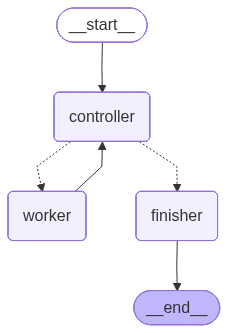

  controller: count=1
  worker: 작업 수행 (count=1)
  controller: count=2
  worker: 작업 수행 (count=2)
  controller: count=3
  finisher: 모든 작업 완료!

최종 상태: count=3, status='완료'



In [20]:
# 같은 루프 로직을 조건부 엣지로 구현해요 — Command 버전과 비교해보세요!
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


class LoopStateCE(TypedDict):
    count: int
    status: str


# --- 노드 함수: 상태 업데이트만 담당해요 (분기 로직 없음!) ---
def controller_node_ce(state: LoopStateCE):
    """controller 노드: count만 증가시켜요. 분기 판단은 하지 않아요."""
    new_count = state["count"] + 1
    print(f"  controller: count={new_count}")
    return {"count": new_count}  # 순수하게 업데이트만!


# --- 라우팅 함수: 분기 판단만 담당해요 (상태 업데이트 없음!) ---
def routing_function(state: LoopStateCE) -> str:
    """별도의 라우팅 함수: 상태를 보고 다음 노드만 결정해요"""
    return "worker" if state["count"] < 3 else "finisher"


def worker_node_ce(state: LoopStateCE):
    """반복 작업을 수행하고 상태 메시지를 설정해요"""
    print(f"  worker: 작업 수행 (count={state['count']})")
    return {"status": f"반복 {state['count']}회 진행 중"}


def finisher_node_ce(state: LoopStateCE):
    """작업을 마무리하고 완료 상태를 설정해요"""
    print(f"  finisher: 모든 작업 완료!")
    return {"status": "완료"}


# 그래프 구성 — 조건부 엣지 사용
builder = StateGraph(LoopStateCE)
builder.add_node("controller", controller_node_ce)
builder.add_node("worker", worker_node_ce)
builder.add_node("finisher", finisher_node_ce)

builder.add_edge(START, "controller")

# Command 대신 add_conditional_edges로 라우팅을 정의해요
builder.add_conditional_edges(
    "controller",
    routing_function,  # 별도의 라우팅 함수가 필요해요
    {"worker": "worker", "finisher": "finisher"}
)
builder.add_edge("worker", "controller")  # worker → controller (루프)
builder.add_edge("finisher", END)

graph_ce = builder.compile()

# 그래프 흐름: START → controller → worker/finisher → ... → END
# controller: count만 증가 (분기 없음)
# routing_function: count를 보고 worker 또는 finisher로 분기해요
display(Image(graph_ce.get_graph().draw_mermaid_png()))

# 실행 — Command 버전과 동일한 결과가 나와요
# === 조건부 엣지 버전 실행 ===
result = graph_ce.invoke({"count": 0, "status": "시작"})
print(f"\n최종 상태: count={result['count']}, status='{result['status']}'")

print()
# 비교 포인트:
#   Command 버전  → controller_node 1개가 업데이트 + 라우팅을 동시에 처리
#   조건부 엣지 버전 → controller_node_ce(업데이트) + routing_function(분기) 2개로 분리
#   → 역할은 명확하게 나뉘지만, 코드가 더 길어져요

## 7. 재귀 제한 (Recursion Limit)

루프가 있는 그래프는 무한히 실행될 수 있어요. LangGraph는 `recursion_limit`으로 안전장치를 제공해요.

| 설정 | 기본값 | 동작 |
|------|--------|------|
| `recursion_limit=25` | 25 | 25번 노드 실행 후 `GraphRecursionError` 발생 |
| `recursion_limit=100` | - | 더 많은 반복 허용 |

```python
# config에서 재귀 제한을 설정해요
graph.invoke(inputs, config={"recursion_limit": 10})
```

> ⚠️ **자주 하는 실수**: 재귀 제한을 너무 높게 설정하면, 실제 무한 루프 버그가 발생할 때 많은 리소스를 낭비하게 돼요. 복잡한 에이전트라도 명확한 종료 조건을 설계하는 게 중요해요.

In [21]:
# 재귀 제한 동작을 확인해요
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.errors import GraphRecursionError


class CountState(TypedDict):
    value: int


def increment(state: CountState):
    """값을 1씩 증가시키는 노드"""
    new_value = state["value"] + 1
    print(f"  현재 값: {new_value}")
    return {"value": new_value}


def should_stop(state: CountState) -> str:
    """종료 조건: 50 이상이면 END, 아니면 계속 반복"""
    return "end" if state["value"] >= 50 else "continue"


# 루프 그래프 구성
builder = StateGraph(CountState)
builder.add_node("increment", increment)
builder.add_edge(START, "increment")
builder.add_conditional_edges(
    "increment",
    should_stop,
    {"continue": "increment", "end": END}  # "continue" 시 자기 자신으로 루프
)
graph = builder.compile()

# recursion_limit=7로 테스트: 7번 실행 후 GraphRecursionError 발생
# === recursion_limit=7로 실행 ===
try:
    result = graph.invoke({"value": 0}, config={"recursion_limit": 7})
    print(f"최종 값: {result['value']}")
except GraphRecursionError:
    # [GraphRecursionError] 재귀 제한에 도달했어요. 그래프 실행이 중단됐어요.
    pass

print()

# recursion_limit=60으로 실행: 50에 도달해 정상 종료
# === recursion_limit=60으로 실행 ===
result = graph.invoke({"value": 0}, config={"recursion_limit": 60})
print(f"최종 값: {result['value']} (정상 종료)")

  현재 값: 1
  현재 값: 2
  현재 값: 3
  현재 값: 4
  현재 값: 5
  현재 값: 6
  현재 값: 7

  현재 값: 1
  현재 값: 2
  현재 값: 3
  현재 값: 4
  현재 값: 5
  현재 값: 6
  현재 값: 7
  현재 값: 8
  현재 값: 9
  현재 값: 10
  현재 값: 11
  현재 값: 12
  현재 값: 13
  현재 값: 14
  현재 값: 15
  현재 값: 16
  현재 값: 17
  현재 값: 18
  현재 값: 19
  현재 값: 20
  현재 값: 21
  현재 값: 22
  현재 값: 23
  현재 값: 24
  현재 값: 25
  현재 값: 26
  현재 값: 27
  현재 값: 28
  현재 값: 29
  현재 값: 30
  현재 값: 31
  현재 값: 32
  현재 값: 33
  현재 값: 34
  현재 값: 35
  현재 값: 36
  현재 값: 37
  현재 값: 38
  현재 값: 39
  현재 값: 40
  현재 값: 41
  현재 값: 42
  현재 값: 43
  현재 값: 44
  현재 값: 45
  현재 값: 46
  현재 값: 47
  현재 값: 48
  현재 값: 49
  현재 값: 50
최종 값: 50 (정상 종료)


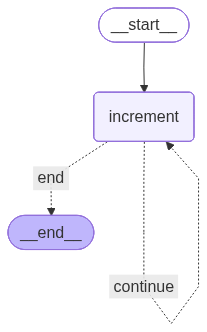

In [22]:
# 그래프 흐름: START → increment → increment → ... → END
# increment 노드: 값을 1씩 증가시켜요
# 조건부 엣지: 50 미만이면 자기 자신으로 루프, 50 이상이면 END로 이동해요
display(Image(graph.get_graph().draw_mermaid_png()))

## 8. 다중 스키마 (Multiple Schemas)

그래프 전체에서 같은 State를 공유하는 것이 일반적이지만, 필요에 따라 **입력/출력 스키마를 분리**할 수 있어요.

| 방식 | 설명 | 사용 시점 |
|------|------|-----------|
| 단일 State | 그래프 전체가 같은 타입 사용 | 대부분의 경우 |
| `input_schema` / `output_schema` | 입출력 스키마 별도 정의 | API 서버, 외부에 노출하는 인터페이스 |
| 내부 State 분리 | 중간 계산에만 쓰는 필드 숨기기 | 민감한 중간 데이터 |

> 💡 **실무 팁**: 외부에 그래프를 서비스로 노출할 때는 입력/출력 스키마를 명시적으로 분리하면 API 문서가 자동으로 생성되고 사용자 실수를 줄일 수 있어요.

In [23]:
# 입출력 스키마를 분리한 그래프 예시예요
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


# 외부에 노출할 입력 스키마
class InputSchema(TypedDict):
    question: str  # 사용자 질문


# 내부 처리에서만 사용하는 전체 상태
class InternalState(TypedDict):
    question: str
    intermediate_result: str  # 내부 중간 결과 (외부에 노출 안 함)
    answer: str               # 최종 답변


# 외부에 노출할 출력 스키마
class OutputSchema(TypedDict):
    answer: str  # 최종 답변만 노출


def analyze_node(state: InternalState):
    """질문을 분석하는 노드 (중간 결과 생성)"""
    intermediate = f"'{state['question']}' 분석 중..."  # 내부 처리 결과
    return {"intermediate_result": intermediate}


def answer_node(state: InternalState):
    """최종 답변을 생성하는 노드"""
    answer = f"질문 '{state['question']}'에 대한 답변이에요."
    return {"answer": answer}


# StateGraph에 input_schema/output_schema로 스키마를 지정할 수 있어요 (LangGraph V0.5+)
builder = StateGraph(
    InternalState,
    input_schema=InputSchema,    # 외부 입력은 question만 (V1 API)
    output_schema=OutputSchema   # 외부 출력은 answer만 (V1 API)
)
builder.add_node("analyze", analyze_node)
builder.add_node("answer", answer_node)
builder.add_edge(START, "analyze")
builder.add_edge("analyze", "answer")
builder.add_edge("answer", END)

graph = builder.compile()

# 입력: question만 있는 딕셔너리
result = graph.invoke({"question": "LangGraph란 무엇인가요?"})

# === 출력 스키마에 정의된 필드만 반환돼요 ===
print(f"반환된 키: {list(result.keys())}")
print(f"answer: {result['answer']}")
# intermediate_result는 외부에 노출되지 않아요

반환된 키: ['answer']
answer: 질문 'LangGraph란 무엇인가요?'에 대한 답변이에요.


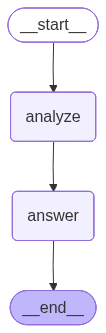

In [24]:
# 그래프 흐름: START → analyze → answer → END
# analyze 노드: 질문을 분석하고 중간 결과를 생성해요
# answer 노드: 분석 결과를 기반으로 최종 답변을 생성해요
display(Image(graph.get_graph().draw_mermaid_png()))

## 9. 그래프 스트리밍 실행

`invoke()`는 최종 결과만 반환하지만, `stream()`은 **각 노드 실행 결과를 실시간으로 받을 수 있어요**.

| 모드 | 설명 | 사용 시점 |
|------|------|-----------|
| `stream_mode="updates"` | 각 노드가 업데이트한 State 변경분 | 노드별 진행 상황 추적 |
| `stream_mode="values"` | 각 노드 실행 후 전체 State | 전체 State 스냅샷 필요 시 |

> 💡 **실무 팁**: 실제 애플리케이션에서는 `invoke()` 대신 `stream()`을 사용해 사용자에게 중간 진행 상황을 보여주는 게 더 좋은 UX를 제공해요.

In [25]:
# 앞서 만든 파이프라인 그래프를 스트리밍 모드로 실행해요
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END


class StreamState(TypedDict):
    text: str


def step1(state: StreamState):
    return {"text": state["text"] + " [1단계 완료]"}


def step2(state: StreamState):
    return {"text": state["text"] + " [2단계 완료]"}


def step3(state: StreamState):
    return {"text": state["text"] + " [3단계 완료]"}


builder = StateGraph(StreamState)
builder.add_node("step1", step1)
builder.add_node("step2", step2)
builder.add_node("step3", step3)
builder.add_edge(START, "step1")
builder.add_edge("step1", "step2")
builder.add_edge("step2", "step3")
builder.add_edge("step3", END)
stream_graph = builder.compile()

# === stream_mode='updates' (각 노드의 변경분) ===
for chunk in stream_graph.stream(
    {"text": "시작"},
    stream_mode="updates"   # 각 노드가 업데이트한 변경분만 받아요
):
    for node_name, node_output in chunk.items():
        print(f"  [{node_name}] → {node_output}")

print()
# === stream_mode='values' (매 스텝의 전체 State) ===
for state_snapshot in stream_graph.stream(
    {"text": "시작"},
    stream_mode="values"    # 매 스텝마다 전체 State 스냅샷을 받아요
):
    print(f"  현재 State: {state_snapshot}")

  [step1] → {'text': '시작 [1단계 완료]'}
  [step2] → {'text': '시작 [1단계 완료] [2단계 완료]'}
  [step3] → {'text': '시작 [1단계 완료] [2단계 완료] [3단계 완료]'}

  현재 State: {'text': '시작'}
  현재 State: {'text': '시작 [1단계 완료]'}
  현재 State: {'text': '시작 [1단계 완료] [2단계 완료]'}
  현재 State: {'text': '시작 [1단계 완료] [2단계 완료] [3단계 완료]'}


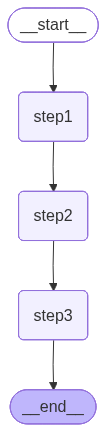

In [26]:
# 그래프 흐름: START → step1 → step2 → step3 → END
# 각 step 노드: 텍스트에 단계 완료 메시지를 추가해요
display(Image(stream_graph.get_graph().draw_mermaid_png()))

## 10. 종합 실습

지금까지 배운 내용을 종합해서 **텍스트 처리 파이프라인**을 만들어봐요. 입력 텍스트의 언어를 감지하고, 언어에 따라 다른 처리 경로로 분기해요.

> 🎯 **강의 포인트**: 실제 에이전트를 설계할 때는 이 패턴을 확장해요. 언어 감지 → 언어별 처리 → 결과 집계. 다음 노트북에서는 이 패턴에 LLM을 연결할 거예요.

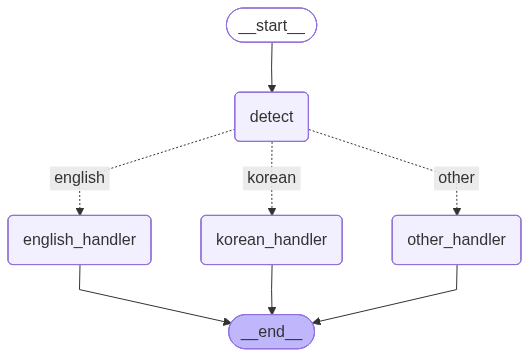

In [27]:
# ============================================================
# TODO: 아래 라우팅 함수를 완성해보세요!
# 힌트: state["language"] 값이 "ko"이면 "korean", "en"이면 "english", 
#       그 외에는 "other"를 반환해요
# 예상 결과: 한국어 입력 → korean_handler, 영어 입력 → english_handler
# ============================================================
from typing import Annotated
from typing_extensions import TypedDict
from operator import add
from langgraph.graph import StateGraph, START, END


class ProcessState(TypedDict):
    text: str                               # 원본 텍스트
    language: str                           # 감지된 언어
    processed: Annotated[list[str], add]    # 처리 단계 기록
    result: str                             # 최종 결과


def detect_language(state: ProcessState):
    """텍스트의 언어를 감지해요 (간단한 규칙 기반)"""
    text = state["text"]
    # 한글 유니코드 범위로 언어 감지
    has_korean = any('\uAC00' <= c <= '\uD7A3' for c in text)
    language = "ko" if has_korean else "en"
    return {
        "language": language,
        "processed": [f"언어 감지: {language}"]
    }


def route_by_language(state: ProcessState) -> str:
    """감지된 언어에 따라 라우팅 키를 반환해요"""
    # TODO: 여기를 완성해보세요
    # state["language"]가 "ko"이면 "korean",
    # "en"이면 "english", 그 외는 "other"를 반환하면 돼요
    if state["language"] == "ko":
        return "korean"
    elif state["language"] == "en":
        return "english"
    else:
        return "other"


def korean_handler(state: ProcessState):
    """한국어 처리 노드"""
    return {
        "result": f"[한국어 처리] {state['text']}",
        "processed": ["한국어 핸들러 실행"]
    }


def english_handler(state: ProcessState):
    """영어 처리 노드"""
    return {
        "result": f"[English Handler] {state['text']}",
        "processed": ["english handler executed"]
    }


def other_handler(state: ProcessState):
    """기타 언어 처리 노드"""
    return {
        "result": f"[기타 언어] {state['text']}",
        "processed": ["기타 언어 핸들러 실행"]
    }


# 그래프 구성
builder = StateGraph(ProcessState)
builder.add_node("detect", detect_language)
builder.add_node("korean_handler", korean_handler)
builder.add_node("english_handler", english_handler)
builder.add_node("other_handler", other_handler)

builder.add_edge(START, "detect")
builder.add_conditional_edges(
    "detect",
    route_by_language,
    {
        "korean": "korean_handler",
        "english": "english_handler",
        "other": "other_handler"
    }
)
builder.add_edge("korean_handler", END)
builder.add_edge("english_handler", END)
builder.add_edge("other_handler", END)

graph = builder.compile()
# 그래프 흐름: START → detect → korean_handler/english_handler/other_handler → END
# detect 노드: 텍스트의 언어를 감지해요
# 조건부 엣지: 감지된 언어에 따라 해당 핸들러 노드로 분기해요
display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
# 테스트 실행
test_cases = [
    "안녕하세요! LangGraph 공부 중이에요.",
    "Hello! I'm learning LangGraph.",
]

for text in test_cases:
    result = graph.invoke({"text": text})
    print(f"입력: {text[:30]}..." if len(text) > 30 else f"입력: {text}")
    print(f"처리 단계: {result['processed']}")
    print(f"결과: {result['result']}")
    print()

입력: 안녕하세요! LangGraph 공부 중이에요.
처리 단계: ['언어 감지: ko', '한국어 핸들러 실행']
결과: [한국어 처리] 안녕하세요! LangGraph 공부 중이에요.

입력: Hello! I'm learning LangGraph.
처리 단계: ['언어 감지: en', 'english handler executed']
결과: [English Handler] Hello! I'm learning LangGraph.



## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **StateGraph**: `TypedDict`로 State를 정의하고, `add_node()` / `add_edge()`로 조립한 뒤 `compile()`로 실행 가능한 그래프를 생성해요
- **리듀서(Reducer)**: `Annotated[타입, 리듀서함수]`로 State 필드의 업데이트 방식을 결정해요. 기본은 덮어쓰기, `operator.add`는 리스트 누적, `add_messages`는 메시지 ID 기반 병합이에요
- **일반 엣지**: `add_edge(source, target)`으로 항상 고정된 경로를 정의해요
- **조건부 엣지**: `add_conditional_edges(source, routing_fn, path_map)`으로 상태 기반 동적 분기를 구현해요
- **Send**: 조건부 엣지에서 `Send` 리스트를 반환하면 여러 노드 인스턴스를 병렬로 실행해요 (Map-Reduce 패턴)
- **Command**: `Command(update=..., goto=...)`로 상태 업데이트와 라우팅을 하나의 반환값으로 처리해요
- **재귀 제한**: `config={"recursion_limit": N}`으로 무한 루프를 방지하고, 한도 초과 시 `GraphRecursionError`가 발생해요
- **스트리밍**: `stream(mode="updates")`로 각 노드의 실행 결과를 실시간으로 받을 수 있어요

## 다음 노트북 예고

다음 `05-ChatBot.ipynb`에서는 **StateGraph에 실제 LLM을 연결해 대화형 챗봇**을 만들어요. 이 노트북에서 배운 `StateGraph`, `add_messages` 리듀서, `MessagesState`를 모두 활용해서 대화 이력을 유지하는 챗봇을 구현할 거예요.

## 부록: Command로 동적 병렬 fan-out 구현하기

앞의 5장 예제는 LangGraph 문서의 전형적인 Map-Reduce 패턴처럼 `add_conditional_edges()`에서 `Send` 리스트를 반환했어요. 같은 fan-out을 노드 내부에서 더 직접 표현하고 싶다면 `Command.goto`에 `Send` 리스트를 넣을 수 있어요.

이 패턴은 **상태 업데이트와 병렬 분배를 같은 노드에서 함께 처리**하고 싶을 때 유용합니다.

```python
return Command(
    update={"dispatch_count": len(topics)},
    goto=[Send("process_single_topic", {"topic": topic}) for topic in topics],
)
```

> 정리하면, `Command`가 라우팅의 주체가 되고 `Send`는 각 병렬 인스턴스에 전달할 개별 State payload를 담는 역할을 해요.

In [ ]:
# Command.goto에 Send 리스트를 넣어 Map-Reduce fan-out을 구현하는 예시예요
from typing import Annotated, Literal
from typing_extensions import TypedDict
from operator import add
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, Send
from IPython.display import Image, display


# 전체 작업 상태
class CommandBatchState(TypedDict):
    topics: list[str]                          # 처리할 주제 목록
    dispatch_count: int                        # Command.update로 기록할 분배 개수
    results: Annotated[list[str], add]          # 처리 결과 (add 리듀서로 병합)


# 개별 작업 상태 (각 병렬 인스턴스가 받는 상태)
class CommandSingleTopicState(TypedDict):
    topic: str  # 단일 주제


def prepare_with_command(
    state: CommandBatchState,
) -> Command[Literal["process_single_topic_with_command"]]:
    """처리할 주제를 준비하고, Command로 병렬 실행을 트리거하는 노드"""
    topics = state["topics"]
    print(f"  처리할 주제: {topics}")

    return Command(
        # 상태 업데이트와 라우팅을 하나의 반환값으로 결합해요
        update={"dispatch_count": len(topics)},
        # Send 리스트를 goto에 넣으면 각 항목이 병렬 노드 인스턴스로 전달돼요
        goto=[
            Send("process_single_topic_with_command", {"topic": topic})
            for topic in topics
        ],
    )


def process_single_topic_with_command(state: CommandSingleTopicState):
    """단일 주제를 처리하는 노드 (병렬로 여러 번 실행돼요)"""
    topic = state["topic"]
    result = f"{topic}: 처리 완료"
    print(f"  병렬 처리 중: '{topic}'")
    return {"results": [result]}  # 리스트로 반환해야 add 리듀서로 병합돼요


# 그래프 구성
command_builder = StateGraph(CommandBatchState)
command_builder.add_node("prepare_with_command", prepare_with_command)
command_builder.add_node(
    "process_single_topic_with_command",
    process_single_topic_with_command,
)

command_builder.add_edge(START, "prepare_with_command")

# 별도의 add_conditional_edges 없이 prepare_with_command 노드의 Command.goto가 다음 노드를 결정해요
command_builder.add_edge("process_single_topic_with_command", END)

command_graph = command_builder.compile()

# 세 주제를 병렬로 처리해요
command_result = command_graph.invoke({
    "topics": ["파이썬", "LangGraph", "AI 에이전트"]
})
print(f"\n분배한 작업 수: {command_result['dispatch_count']}개")
print(f"처리 결과 ({len(command_result['results'])}개):")
for r in command_result["results"]:
    print(f"  - {r}")

# 그래프 흐름: START → prepare_with_command → process_single_topic_with_command(병렬) → END
# prepare_with_command: Command.update로 분배 개수를 기록하고, Command.goto로 병렬 실행을 트리거해요
# process_single_topic_with_command: Command.goto 안의 Send payload로 각 주제를 병렬 처리해요
# 결과는 add 리듀서로 자동 병합돼요
display(Image(command_graph.get_graph().draw_mermaid_png()))